In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sklearn.metrics as sm
import math
%matplotlib inline

In [2]:
filename = '72merged.csv'
data = pd.read_csv(filename)

In [3]:
dist_points_from_cluster_center = []
K = range(1,10)
for no_of_clusters in K:
  k_model = KMeans(n_clusters=no_of_clusters)
  k_model.fit(data)
  dist_points_from_cluster_center.append(k_model.inertia_)

In [4]:
#dist_points_from_cluster_center

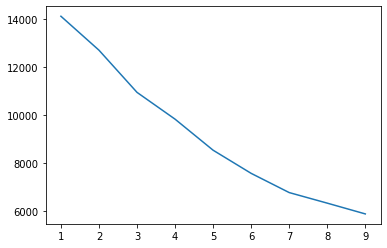

In [5]:
plt.plot(K, dist_points_from_cluster_center)

In [6]:
# Function to find distance
# https://www.geeksforgeeks.org/perpendicular-distance-
# between-a-point-and-a-line-in-2-d/
def calc_distance(x1, y1, a, b, c):
  d = abs((a * x1 + b * y1 + c)) / (math.sqrt(a * a + b * b))
  return d

In [7]:
# (y1 – y2)x + (x2 – x1)y + (x1y2 – x2y1) = 0
# https://bobobobo.wordpress.com/2008/01/07/solving-linear-equations-ax-by-c-0/
a = dist_points_from_cluster_center[0] - dist_points_from_cluster_center[8]
b = K[8] - K[0]
c1 = K[0] * dist_points_from_cluster_center[8]
c2 = K[8] * dist_points_from_cluster_center[0]
c = c1 - c2

In [8]:
distance_of_points_from_line = []
for k in range(9):
  distance_of_points_from_line.append(
      calc_distance(K[k], dist_points_from_cluster_center[k], a, b, c))

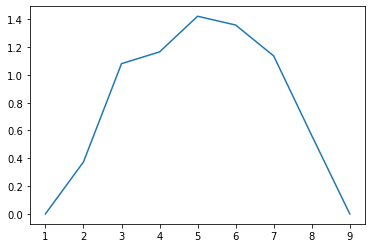

In [9]:
plt.plot(K, distance_of_points_from_line)

In [10]:
print("Optimum value of k=" + str(distance_of_points_from_line.index(max(distance_of_points_from_line))+1))

Optimum value of k=5
